# SSNE | Lab 4 | Regularyzacje / przeuczenie / tips & tricks

## Prerequisites

In [3]:
# !pip install torchvision seaborn tqdm
!uv add torchvision seaborn tqdm

Resolved 81 packages in 372ms                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)----     0 B/288.00 KiB                    
⠙ Preparing packages... (0/2)---- 16.00 KiB/288.00 KiB                  
⠙ Preparing packages... (0/2)---- 32.00 KiB/288.00 KiB                  
⠙ Preparing packages... (0/2)---- 48.00 KiB/288.00 KiB                  
⠙ Preparing packages... (0/2)---- 61.02 KiB/288.00 KiB                  
⠙ Preparing packages... (0/2)---- 77.02 KiB/288.00 KiB                  
⠙ Preparing packages... (0/2)---- 93.02 KiB/288.00 KiB                  
⠙ Preparing packages... (0/2)---- 109.02 KiB/288.00 KiB                 
seaborn    ------------------------------ 109.02 KiB/288.00 KiB
⠙ Preparing packages... (0/2)-----     0 B/7.70 MiB                     
seaborn    ------------------------------ 125.02 KiB/288.00 KiB
⠙ Preparing packages... (0/2)-----     0 B/7.70 MiB             

In [1]:
import torch, torchvision
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import numpy as np
import pandas as pd
import torch.utils.data as data
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)  # multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA

## Trick #1 - Batch Normalization // BatchNorm
Batch-Normalization is an algorithmic method which makes the training of Deep Neural Networks (DNN) faster and more stable. 

In [3]:
# data.csv from Mini-Projekt 1

train_data = pd.read_csv("https://drive.google.com/uc?export=download&id=19lok0wZOqUThdF8wv_hnVIaIQ-VRD0RV",index_col=0)
train = train_data.drop(columns=["casual","registered","cnt","dteday","season","yr","mnth"])
train_dataset = data.TensorDataset(torch.from_numpy(train.values).float(),torch.from_numpy(train_data.values[:,-1].astype(float)).float())
data_loader  = data.DataLoader(train_dataset, batch_size=256, shuffle=True)

In [4]:
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.lin1 =nn.Linear(9, 48)
        self.act1 =nn.ReLU()
        self.lin2 =nn.Linear(48, 24)
        self.act2 =nn.ReLU()
        self.lin3 =nn.Linear(24, 1)


    def forward(self, x):
        x = self.lin1(x)
        x = self.act1(x)
        x = self.lin2(x)
        x = self.act2(x)
        x = self.lin3(x)
        return x

In [5]:
class MyNetBN(nn.Module):
    def __init__(self):
        super(MyNetBN, self).__init__()
        self.lin1 =nn.Linear(9, 48)  # 28 x 28 = 784
        self.bn1 = nn.BatchNorm1d(48)
        self.act1 =nn.ReLU()
        self.lin2 =nn.Linear(48, 24)
        self.bn2 = nn.BatchNorm1d(24)
        self.act2 =nn.ReLU()
        self.lin3 =nn.Linear(24, 1)


    def forward(self, x):
        x = self.lin1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.lin2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.lin3(x)
        return x

In [6]:
model = MyNet()
print(model)
model_bn = MyNetBN()
print(model_bn)

MyNet(
  (lin1): Linear(in_features=9, out_features=48, bias=True)
  (act1): ReLU()
  (lin2): Linear(in_features=48, out_features=24, bias=True)
  (act2): ReLU()
  (lin3): Linear(in_features=24, out_features=1, bias=True)
)
MyNetBN(
  (lin1): Linear(in_features=9, out_features=48, bias=True)
  (bn1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU()
  (lin2): Linear(in_features=48, out_features=24, bias=True)
  (bn2): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU()
  (lin3): Linear(in_features=24, out_features=1, bias=True)
)


In [7]:
loss_fn = nn.MSELoss()
opt = optim.SGD(model.parameters(), lr=0.0001, momentum=0.5)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.0001, momentum=0.5)

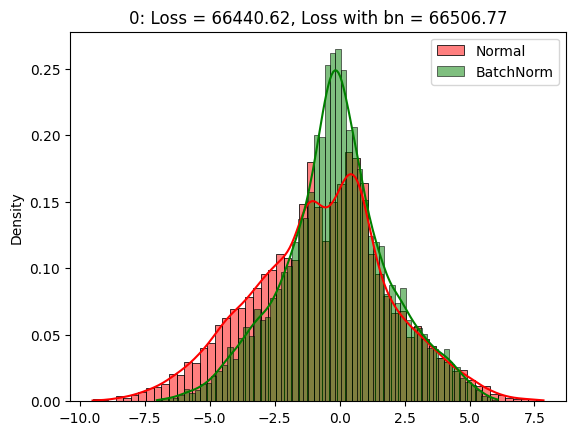

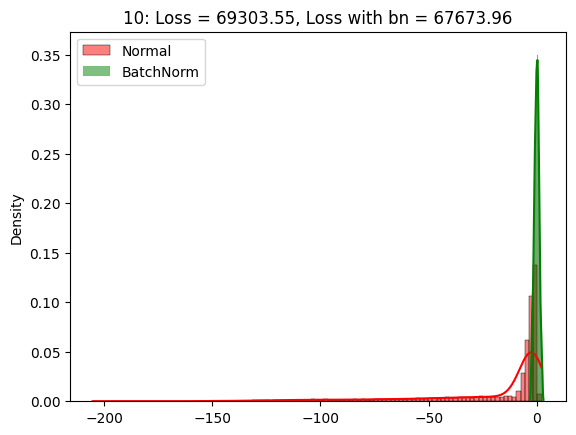

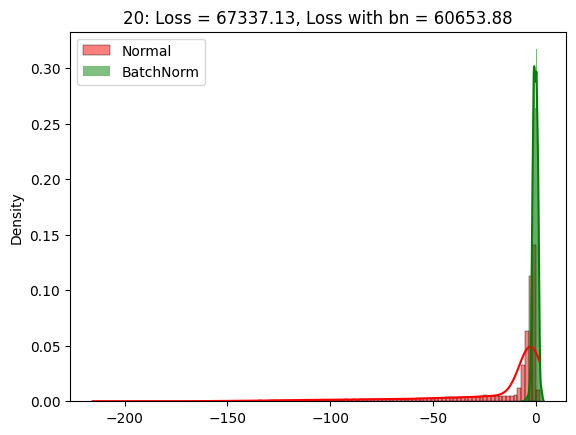

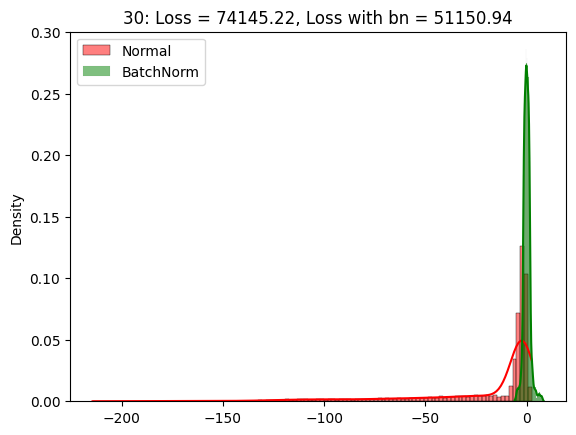

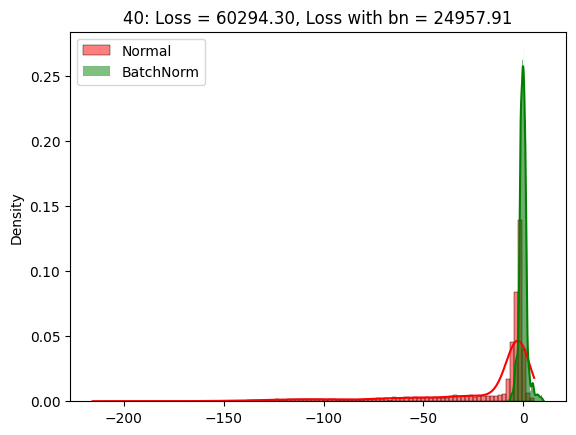

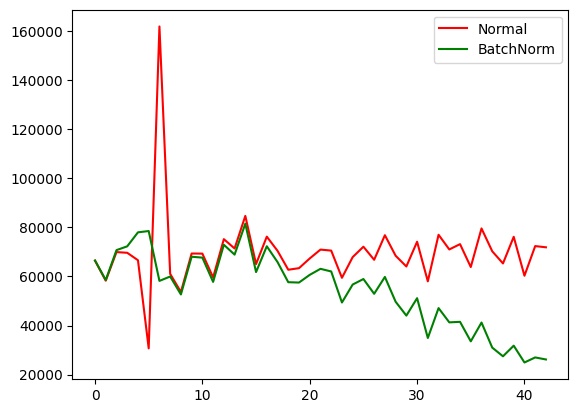

----------------------


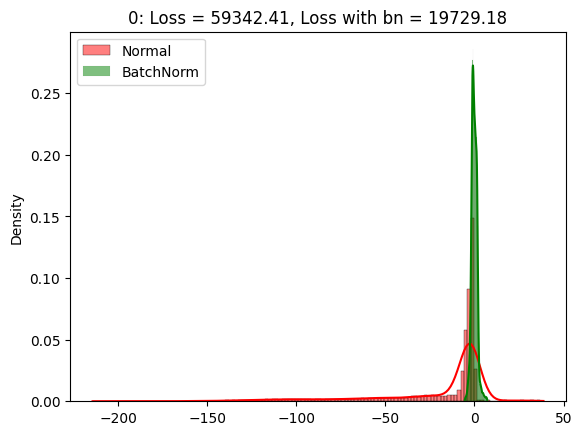

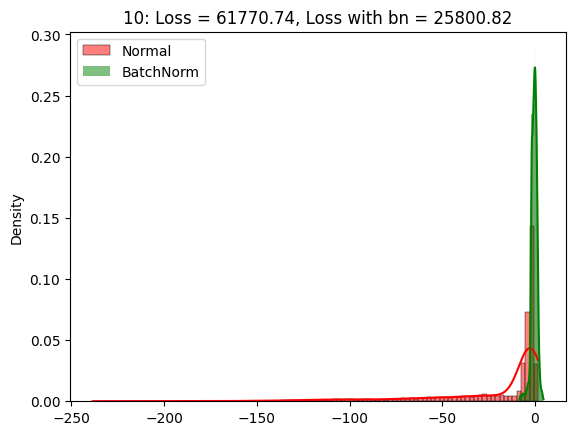

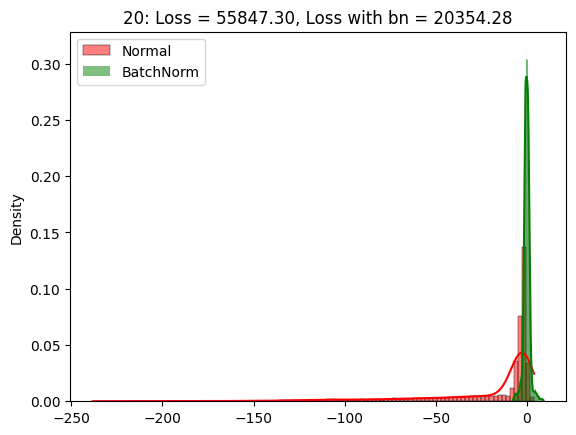

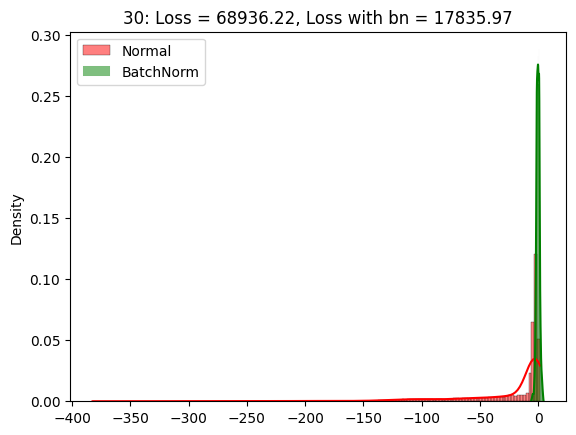

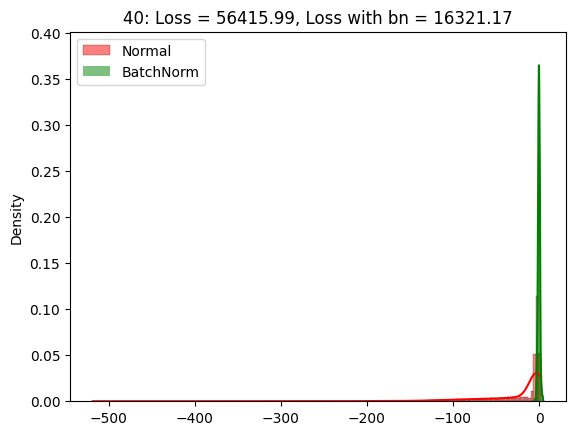

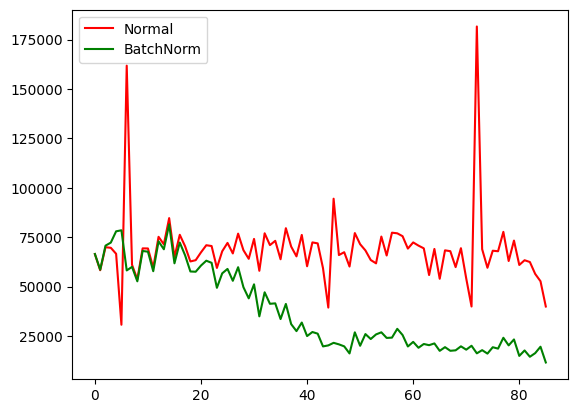

----------------------


In [8]:
loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
    for i, batch in enumerate(data_loader, 0):

        inputs, labels = batch

        # training steps for normal model
        opt.zero_grad()
        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        # training steps for bn model
        opt_bn.zero_grad()
        outputs_bn = model_bn(inputs).squeeze()
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

        if i % 10 == 0:

            inputs = inputs.view(inputs.size(0), -1)

            model.eval()
            model_bn.eval()

            a = model.lin1(inputs)
            a = a.detach().numpy().ravel()
            sns.histplot(a, kde=True, color='r', label='Normal', stat="density")

            b = model_bn.lin1(inputs)
            b = model_bn.bn1(b)
            b = b.detach().numpy().ravel()

            sns.histplot(b, kde=True, color='g', label='BatchNorm', stat="density")
            plt.title('%d: Loss = %0.2f, Loss with bn = %0.2f' % (i, loss.item(), loss_bn.item()))
            plt.legend()
            plt.show()
            plt.pause(0.5)

            model.train()
            model_bn.train()



    plt.plot(loss_arr, 'r', label='Normal')
    plt.plot(loss_bn_arr, 'g', label='BatchNorm')
    plt.legend()
    plt.show()
    print('----------------------')

Visualisation from AI by Hand [here](https://www.byhand.ai/p/batch-normalization-by-hand).

In [9]:
print(f"{model_bn.lin1=}")
print(f"{model_bn.bn1=}")
print(f"-----------------")
print(f"Running mean: {model_bn.bn1.running_mean.data}")
print(f"Running std: {model_bn.bn1.running_var.data}")
print(f"-----------------")
print(f"Scale: {model_bn.bn1.weight.data}")
print(f"Shift: {model_bn.bn1.bias.data}")


model_bn.lin1=Linear(in_features=9, out_features=48, bias=True)
model_bn.bn1=BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
-----------------
Running mean: tensor([ -1.1801,  -2.7009,  -2.9282,  -1.0190,  19.7018,  -2.4084, -10.5718,
         -3.4986,  -3.9609,  -5.2655, -27.7376,   1.5925,   5.2486,  -5.1844,
         38.5735,   4.5549,  -2.6836,  22.1399,  -2.6003,  -3.7974,  -4.8574,
         -2.5258,  -3.7014,   2.4738,  -4.5611,  -4.6698,   9.3495, -11.2409,
         -3.1127,   8.5429,   8.5971,  30.3859,  -3.2220,  -1.8130,  -2.0000,
          9.5676,  -5.7011,  26.7413,   6.2537,  10.4663,  -4.2485,   8.8283,
         -4.5776,   6.8065,  -7.0828,  -9.5817,   0.6422,  -3.5458])
Running std: tensor([3.3220e+00, 2.7837e+00, 4.7826e+00, 1.1989e+00, 1.3324e+02, 3.2824e+00,
        5.0423e+01, 6.1600e+00, 6.7982e+00, 1.0859e+01, 3.0276e+02, 2.6068e+00,
        1.9047e+01, 1.7196e+01, 8.2930e+02, 8.5718e+00, 2.1695e+00, 1.9491e+02,
        2.6812e+00, 4

1. During training:
- Inputs?
- Running mean and std?
- Scale and shift?

2. During evaluation:
- Inputs?
- Running mean and std?
- Scale and shift?


![](https://forums.fast.ai/uploads/default/original/2X/9/998a1be6463260f731481106756034c42040e256.jpg)

## Przeuczanie sieci

In [10]:
mnist_data = torchvision.datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
mnist_data = list(mnist_data)
mnist_train = mnist_data[:20]
mnist_val   = mnist_data[20:1000]

In [11]:
mnist_train[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [16]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.determinstic = True
torch.backends.cudnn.benchmark = False

# device = torch.device("cuda")
device = torch.device("cpu")

In [17]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 800)
        self.act_1 =  nn.Tanh()
        self.layer2 = nn.Linear(800, 800)
        self.act_2 = nn.Tanh()
        self.layer3 = nn.Linear(800, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        activation2 = self.act_2(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

In [18]:
def train(model, train, valid, batch_size=10, num_epochs=1, learn_rate=0.001, weight_decay=0, with_plot=False):
    train_loader = torch.utils.data.DataLoader(train,
                                               batch_size=batch_size,
                                               shuffle=True) # shuffle after every epoch
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learn_rate,momentum=0.9, weight_decay=weight_decay)

    iters, losses, train_acc, val_acc = [], [], [], []

    # training
#     n = 0 # the number of iterations
    idx = 0
    for n in range(num_epochs):
        for imgs, labels in iter(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            model.train()
            out = model(imgs)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()

            # save the current training information
            if idx % 10 == 9:
                iters.append(idx)
                losses.append(float(loss)/batch_size)        # compute *average* loss
                train_acc.append(get_accuracy(model, train)) # compute training accuracy
                val_acc.append(get_accuracy(model, valid))   # compute validation accuracy
            idx+=1
        if n%100==0:
            print(f"Epoch {n}, loss: {loss.item()}")


    if with_plot:
        # plotting
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.title("Training Curve")
        plt.plot(iters, losses, label="Train")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")

        plt.subplot(1,2,2)
        plt.title("Training Curve")
        plt.plot(iters, train_acc, label="Train")
        plt.plot(iters, val_acc, label="Validation")
        plt.xlabel("Iterations")
        plt.ylabel("Training Accuracy")
        plt.legend(loc='best')
        plt.show()


    print("Final Training Accuracy: {}".format(train_acc[-1]))
    print("Final Validation Accuracy: {}".format(val_acc[-1]))


train_acc_loader = torch.utils.data.DataLoader(mnist_train, batch_size=100)
val_acc_loader = torch.utils.data.DataLoader(mnist_val, batch_size=1000)

def get_accuracy(model, data):
    correct = 0
    total = 0
    model.eval() #*********#
    for imgs, labels in torch.utils.data.DataLoader(data, batch_size=64):
        imgs, labels = imgs.to(device), labels.to(device)
        output = model(imgs)
        pred = output.max(1, keepdim=True)[1] # get the index of the max logit
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
    return correct / total

In [19]:
model = MNISTClassifier().to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=False) # with_plot=True

Epoch 0, loss: 2.2815959453582764


/tmp/ipykernel_1211/1051988306.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(loss)/batch_size)        # compute *average* loss


Epoch 100, loss: 0.9364933967590332
Epoch 200, loss: 0.15831056237220764
Epoch 300, loss: 0.0722869485616684
Epoch 400, loss: 0.03468526899814606
Epoch 500, loss: 0.021478045731782913
Epoch 600, loss: 0.020320560783147812
Epoch 700, loss: 0.009400371462106705
Epoch 800, loss: 0.008108416572213173
Epoch 900, loss: 0.008650639094412327
Final Training Accuracy: 1.0
Final Validation Accuracy: 0.5989795918367347


## Trick #2 - Dropout
Maskowanie losowych neuronów w sieci.
Dropout inaczej się w train() i eval().

+ Dropout oryginalnie: [Dropout: A Simple Way to Prevent Neural Networks from Overfitting](https://jmlr.org/papers/v15/srivastava14a.html)

![obrazek](https://miro.medium.com/1*o9j9haCPmXfTBK-qrUJbsQ.png)

+ Dropout w [PyTorchu](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

In [74]:
m = nn.Dropout(p=0.5)
x = torch.randn((1, 6))

m.train()
print(f"x:     {x}")
print(f"train: {m(x)}")         # 1 / (1 - 0.5) = 2

m.eval()
print(f"eval:  {m(x)}")

x:     tensor([[ 0.5736, -0.3453,  0.6480,  1.1651,  1.6395, -0.2785]])
train: tensor([[ 1.1473, -0.6907,  1.2959,  2.3303,  3.2790, -0.5571]])
eval:  tensor([[ 0.5736, -0.3453,  0.6480,  1.1651,  1.6395, -0.2785]])


In [75]:
class MNISTClassifier_Dropout(nn.Module):
    def __init__(self):
        super(MNISTClassifier_Dropout, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 800)
        self.act_1 =  nn.Tanh()
        self.d1 = nn.Dropout(0.8)

        self.layer2 = nn.Linear(800, 800)
        self.act_2 = nn.Tanh()
        self.d2 = nn.Dropout(0.8)

        self.layer3 = nn.Linear(800, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        x = self.d1(activation1)
        activation2 = self.act_2(self.layer2(x))
        x = self.d2(activation2)
        output = self.layer3(x)
        return output

Epoch 0, loss: 2.302685499191284
Epoch 100, loss: 0.8470114469528198
Epoch 200, loss: 0.11981166899204254
Epoch 300, loss: 0.08152414858341217
Epoch 400, loss: 0.04139483720064163
Epoch 500, loss: 0.04425657168030739
Epoch 600, loss: 0.023127565160393715
Epoch 700, loss: 0.006304743234068155
Epoch 800, loss: 0.03156828507781029
Epoch 900, loss: 0.009193174540996552


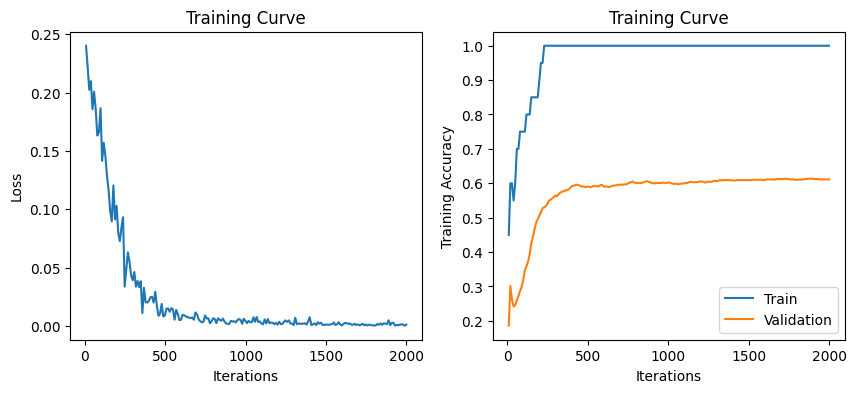

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6112244897959184


In [22]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

model = MNISTClassifier_Dropout().to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

## Trick #3 - regularyzacja wag

### L1 vs L2 Regularization

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*Tyu8vrwWsm0qJ4BhrSdAFA.png)



W torch: domyślnie L2 jako `weight_decay`

Epoch 0, loss: 2.3026845455169678
Epoch 100, loss: 0.8822253942489624
Epoch 200, loss: 0.13872556388378143
Epoch 300, loss: 0.10406637191772461
Epoch 400, loss: 0.05723368376493454
Epoch 500, loss: 0.06893299520015717
Epoch 600, loss: 0.03997452184557915
Epoch 700, loss: 0.013030353002250195
Epoch 800, loss: 0.05836547538638115
Epoch 900, loss: 0.023470886051654816


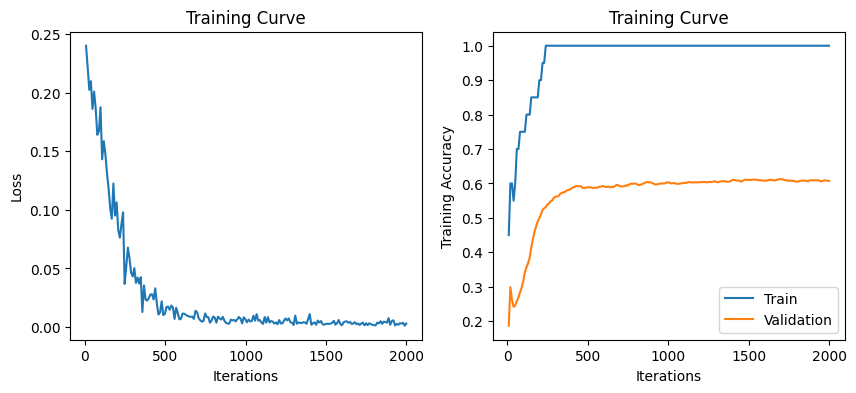

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6071428571428571


In [23]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

model = MNISTClassifier_Dropout().to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, weight_decay=1e-2, with_plot=True)

### Zadanie - własna regularyzacja

In [24]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 800)
        self.act_1 =  nn.Tanh()
        self.layer2 = nn.Linear(800, 800)
        self.act_2 = nn.Tanh()
        self.layer3 = nn.Linear(800, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        activation2 = self.act_2(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

Epoch 0
Epoch 100
Epoch 200
Epoch 300
Epoch 400
Epoch 500
Epoch 600
Epoch 700
Epoch 800
Epoch 900


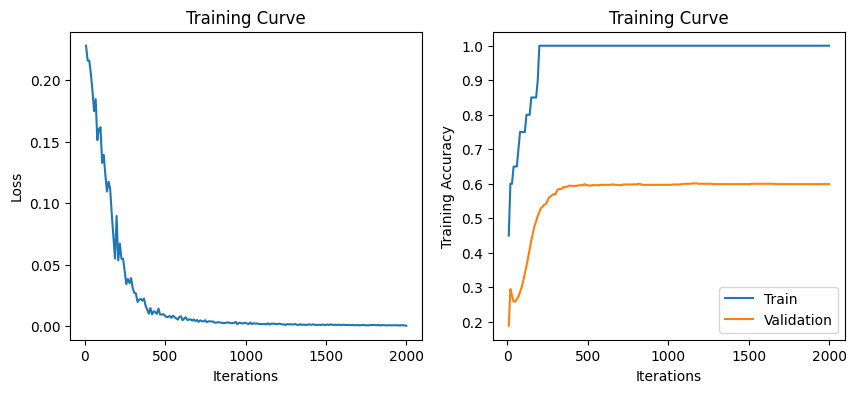

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.5989795918367347


In [25]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# model / optimizer
model = MNISTClassifier().to(device)
train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=10, shuffle=True) # shuffle after every epoch
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

iters, losses, train_acc, val_acc = [], [], [], []

### TODO:
REGULARIZATION_LAMBDA = ...
###

idx = 0
for n in range(1000):
    for imgs, labels in iter(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        model.train()
        out = model(imgs)
        ### TODO:
        # Here propose some form of regularization
        # HINT: check list(model.named_parameters())

        regularization = ...

        loss = criterion(out, labels)
        ###
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


        if idx % 10 == 9:
            iters.append(idx)
            losses.append(float(loss)/10)        # compute *average* loss
            train_acc.append(get_accuracy(model, mnist_train)) # compute training accuracy
            val_acc.append(get_accuracy(model, mnist_val))   # compute validation accuracy
        idx+=1
    if n%100==0:
        print(f"Epoch {n}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Training Curve")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Training Accuracy")
plt.legend(loc='best')
plt.show()


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

## Wielkość sieci a jej jakość

In [26]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [27]:
class MNISTClassifier_parametrized(nn.Module):
    def __init__(self,size_1,size_2):
        super(MNISTClassifier_parametrized, self).__init__()
        self.layer1 = nn.Linear(28 * 28, size_1)
        self.act_1 =  nn.Tanh()
        self.layer2 = nn.Linear(size_1, size_2)
        self.act_2 = nn.Tanh()
        self.layer3 = nn.Linear(size_2, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        activation2 = self.act_2(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

Epoch 0, loss: 2.32747220993042
Epoch 100, loss: 0.18253165483474731
Epoch 200, loss: 0.0437723770737648
Epoch 300, loss: 0.025961611419916153
Epoch 400, loss: 0.013391797430813313
Epoch 500, loss: 0.009858357720077038
Epoch 600, loss: 0.007617415394634008
Epoch 700, loss: 0.006659231148660183
Epoch 800, loss: 0.0070130350068211555
Epoch 900, loss: 0.006383564323186874


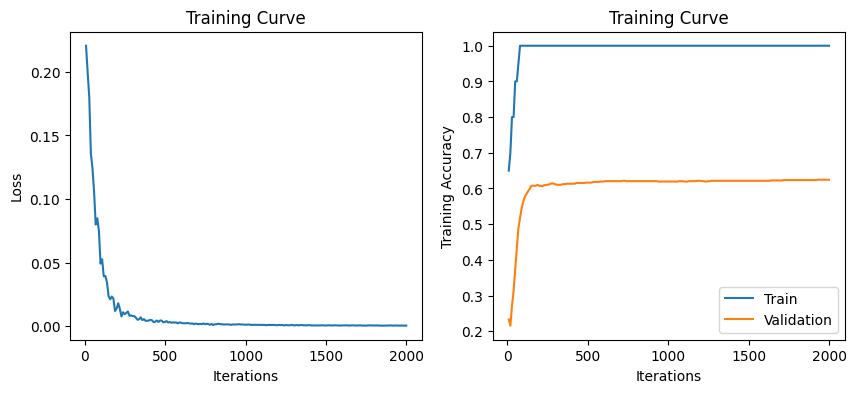

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6244897959183674


In [28]:
set_seed(42)
model = MNISTClassifier_parametrized(5000,3000).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

Epoch 0, loss: 2.30110764503479
Epoch 100, loss: 0.4210239052772522
Epoch 200, loss: 0.10196713358163834
Epoch 300, loss: 0.05147342011332512
Epoch 400, loss: 0.025365540757775307
Epoch 500, loss: 0.01812470331788063
Epoch 600, loss: 0.01020420715212822
Epoch 700, loss: 0.011437492445111275
Epoch 800, loss: 0.008460785262286663
Epoch 900, loss: 0.008747158572077751


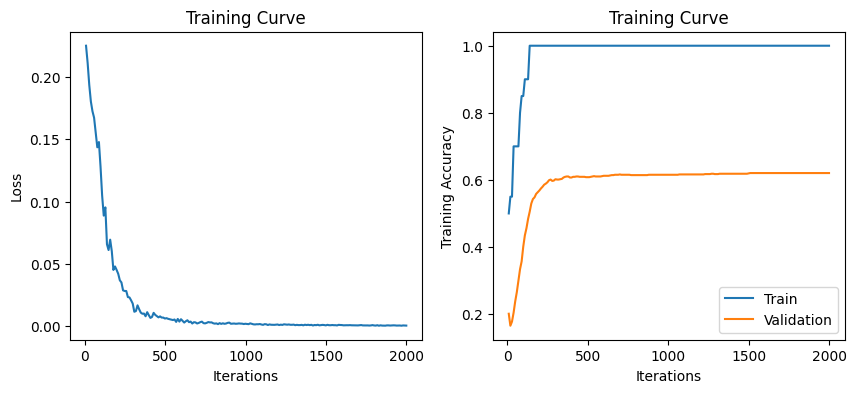

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6204081632653061


In [29]:
set_seed(42)
model = MNISTClassifier_parametrized(2000,1000).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

Epoch 0, loss: 2.2708826065063477
Epoch 100, loss: 0.9515225291252136
Epoch 200, loss: 0.25105157494544983
Epoch 300, loss: 0.07852907478809357
Epoch 400, loss: 0.05120565742254257
Epoch 500, loss: 0.054207246750593185
Epoch 600, loss: 0.03835856914520264
Epoch 700, loss: 0.021471086889505386
Epoch 800, loss: 0.01729140616953373
Epoch 900, loss: 0.01155649684369564


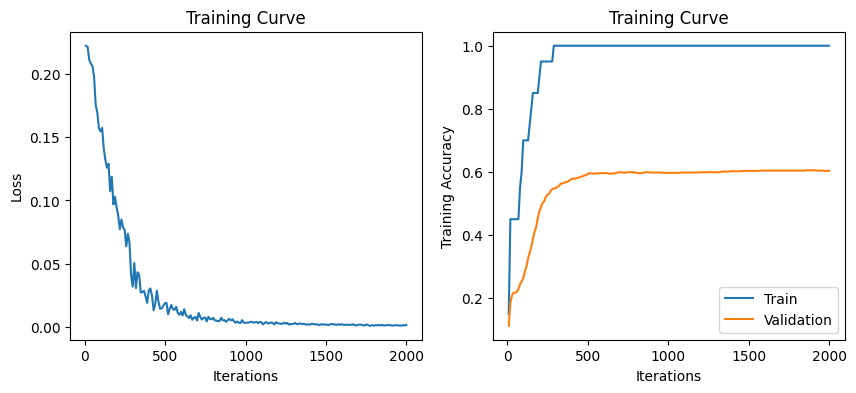

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6030612244897959


In [30]:
set_seed(42)
model = MNISTClassifier_parametrized(1000,100).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

Epoch 0, loss: 2.254729747772217
Epoch 100, loss: 1.4965846538543701
Epoch 200, loss: 1.1340450048446655
Epoch 300, loss: 0.8977096676826477
Epoch 400, loss: 0.6690517663955688
Epoch 500, loss: 0.4263395369052887
Epoch 600, loss: 0.3582146167755127
Epoch 700, loss: 0.24866537749767303
Epoch 800, loss: 0.3209816813468933
Epoch 900, loss: 0.15970128774642944


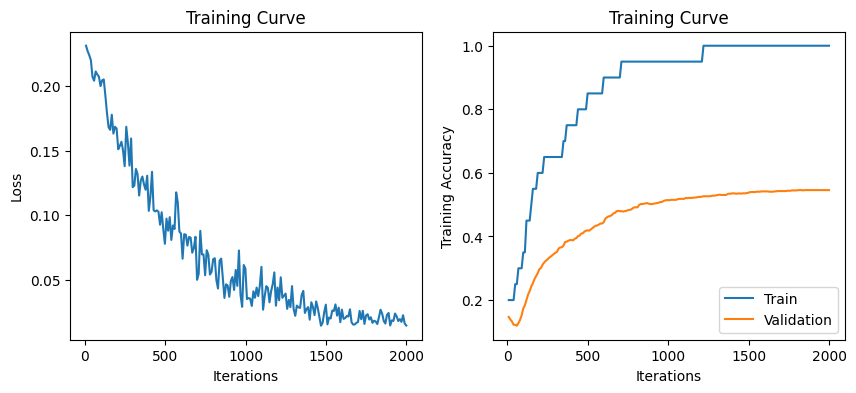

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.5459183673469388


In [31]:
set_seed(42)
model = MNISTClassifier_parametrized(20,10).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

Epoch 0, loss: 2.254729747772217
Epoch 100, loss: 1.4965846538543701
Epoch 200, loss: 1.1340450048446655
Epoch 300, loss: 0.8977096676826477
Epoch 400, loss: 0.6690517663955688
Epoch 500, loss: 0.4263395369052887
Epoch 600, loss: 0.3582146167755127
Epoch 700, loss: 0.24866537749767303
Epoch 800, loss: 0.3209816813468933
Epoch 900, loss: 0.15970128774642944
Epoch 1000, loss: 0.20347347855567932
Epoch 1100, loss: 0.1338428109884262
Epoch 1200, loss: 0.1639551967382431
Epoch 1300, loss: 0.11704619228839874
Epoch 1400, loss: 0.0536762960255146
Epoch 1500, loss: 0.07571212947368622
Epoch 1600, loss: 0.09309002012014389
Epoch 1700, loss: 0.0884980857372284
Epoch 1800, loss: 0.04992974177002907
Epoch 1900, loss: 0.06278902292251587
Epoch 2000, loss: 0.05206422135233879
Epoch 2100, loss: 0.043344032019376755
Epoch 2200, loss: 0.04116654396057129
Epoch 2300, loss: 0.05300980806350708
Epoch 2400, loss: 0.04478836432099342
Epoch 2500, loss: 0.03580934926867485
Epoch 2600, loss: 0.0381569117307662

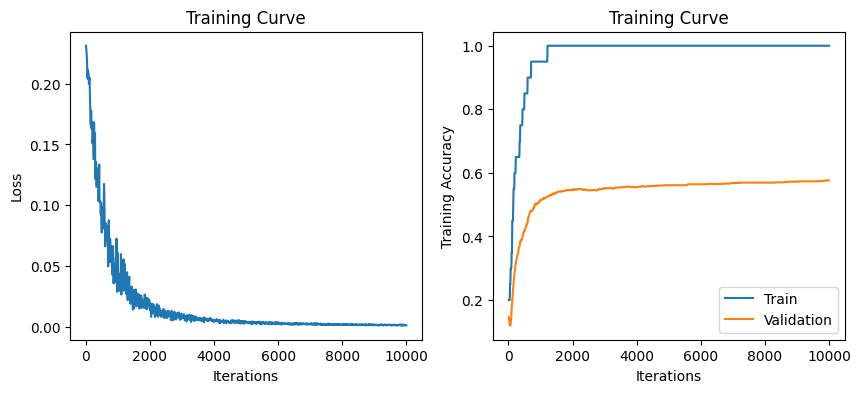

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.576530612244898


In [32]:
set_seed(42)
model = MNISTClassifier_parametrized(20,10).to(device)
train(model, mnist_train, mnist_val, num_epochs=5000, with_plot=True)

## Architecture search

In [33]:
def fast_accuracy(model, data):
    with torch.no_grad():
        correct = 0
        total = 0
        model.eval()
        imgs, labels = data
        output = model(imgs.to(device))
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred).to(device)).sum().item()
        total += imgs.shape[0]
    return correct / total

def train_search(model, train, valid, batch_size=10, num_epochs=1, learn_rate=0.001, weight_decay=0):
    train_loader = torch.utils.data.DataLoader(train,
                                               batch_size=batch_size,
                                               shuffle=True) # shuffle after every epoch
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learn_rate,momentum=0.9, weight_decay=weight_decay)

    iters, losses, train_acc, val_acc = [], [], [], []

    idx = 0
    for n in range(num_epochs):
        for imgs, labels in iter(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            model.train()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    return(fast_accuracy(model, valid))

In [34]:
mnist_val_preprocessed = torch.cat([batch[0] for batch in mnist_val]), torch.tensor([batch[1] for batch in mnist_val])

In [35]:
mnist_data = torchvision.datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
mnist_data = list(mnist_data)
mnist_train = mnist_data[:20]
mnist_val   = mnist_data[20:10000]

In [36]:
first_layer = [2000, 1000, 500, 100, 50, 10]
second_layer = [5000, 2000, 1000, 500, 100, 50, 10]

# # mniej parametrow
# first_layer = [50, 10]
# second_layer = [50, 10]

results = []
for i in range(len(first_layer)):
    for j in range(len(second_layer)):
        set_seed(42)
        model = MNISTClassifier_parametrized(first_layer[i],second_layer[j]).to(device)
        val_acc = train_search(model, mnist_train, mnist_val_preprocessed, num_epochs=1000)
        print(first_layer[i],second_layer[j],val_acc)
        results.append({"first": first_layer[i], "second": second_layer[j],"acc":val_acc})
results = pd.DataFrame(results)

2000 5000 0.6204081632653061
2000 2000 0.6112244897959184
2000 1000 0.6204081632653061
2000 500 0.6255102040816326
2000 100 0.6112244897959184
2000 50 0.5948979591836735
2000 10 0.5591836734693878
1000 5000 0.6122448979591837
1000 2000 0.6030612244897959
1000 1000 0.613265306122449
1000 500 0.6051020408163266
1000 100 0.6030612244897959
1000 50 0.6163265306122448
1000 10 0.5469387755102041
500 5000 0.6173469387755102
500 2000 0.6244897959183674
500 1000 0.6173469387755102
500 500 0.6153061224489796
500 100 0.6071428571428571
500 50 0.5836734693877551
500 10 0.560204081632653
100 5000 0.6091836734693877
100 2000 0.6061224489795919
100 1000 0.6051020408163266
100 500 0.6163265306122448
100 100 0.6010204081632653
100 50 0.5959183673469388
100 10 0.539795918367347
50 5000 0.6040816326530613
50 2000 0.5969387755102041
50 1000 0.5918367346938775
50 500 0.610204081632653
50 100 0.5969387755102041
50 50 0.5785714285714286
50 10 0.4969387755102041
10 5000 0.5959183673469388
10 2000 0.6061224489

In [ ]:
results.to_csv("params_search.csv",index=False)
results = pd.read_csv("params_search.csv")

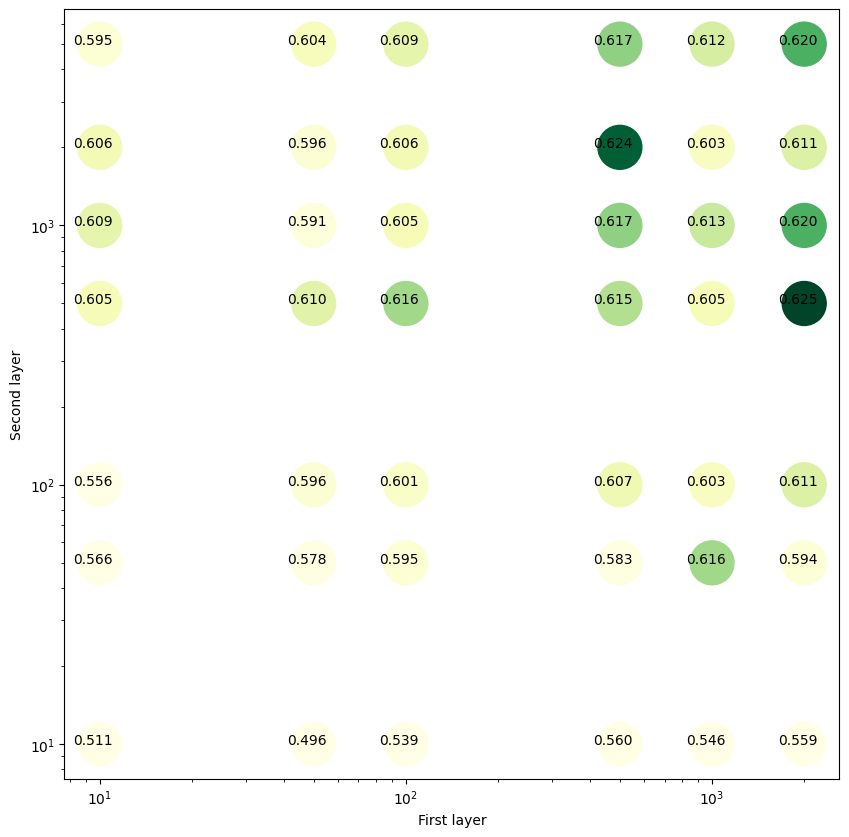

In [38]:
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(results["first"], results["second"], c=np.exp(results.acc*100), cmap="YlGn", s=1000)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("First layer")
plt.ylabel("Second layer")
for idx, row in results.iterrows():
    ax.annotate(str(row.acc)[:5], (row["first"]*0.82, row["second"]))
plt.show()

### Sieć o większej liczbie warstw wymaga dłuższego treningu

In [39]:
class MNISTClassifier_parametrized_3(nn.Module):
    def __init__(self,sizes):
        super(MNISTClassifier_parametrized_3, self).__init__()
        size_in = 28 * 28

        layers = []
        for size in sizes:
            layers.append(nn.Linear(size_in, size))
            layers.append(nn.Tanh())
            size_in = size
        layers.append(nn.Linear(size_in, 10))
        self.layers = nn.Sequential(*layers)

    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        
        output = self.layers(flattened)
        return output

Epoch 0, loss: 2.2955985069274902


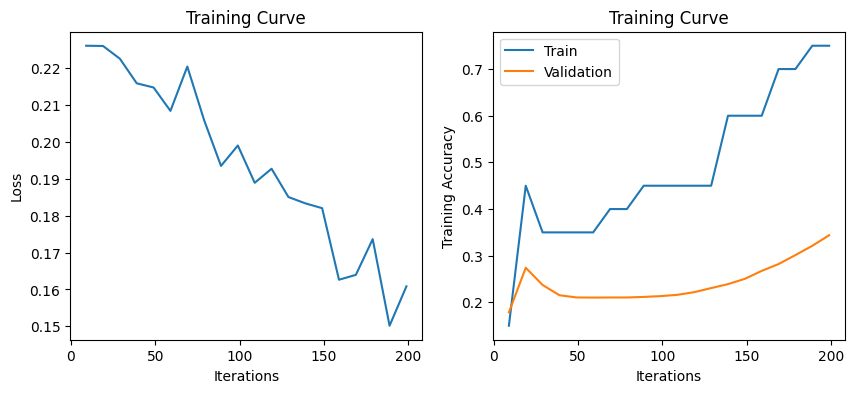

Final Training Accuracy: 0.75
Final Validation Accuracy: 0.3438877755511022


In [40]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000,500,100]).to(device)
train(model, mnist_train, mnist_val, num_epochs=100, with_plot=True)

Epoch 0, loss: 2.2922756671905518


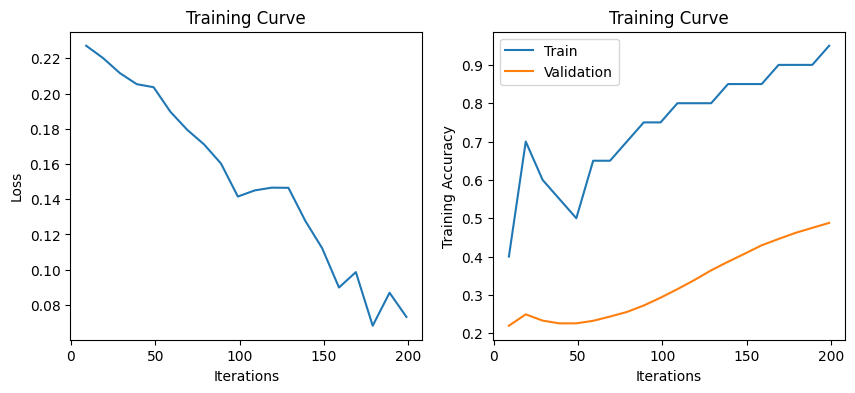

Final Training Accuracy: 0.95
Final Validation Accuracy: 0.4877755511022044


In [41]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000, 500]).to(device)
train(model, mnist_train, mnist_val, num_epochs=100, with_plot=True)

### Większa liczba warstw może prowadzić do przeuczania

Epoch 0, loss: 2.2955985069274902
Epoch 100, loss: 1.4384114742279053
Epoch 200, loss: 0.45347529649734497
Epoch 300, loss: 0.15286780893802643
Epoch 400, loss: 0.08510486781597137
Epoch 500, loss: 0.04410172626376152
Epoch 600, loss: 0.021440992131829262
Epoch 700, loss: 0.020208479836583138
Epoch 800, loss: 0.014600120484828949
Epoch 900, loss: 0.014825520105659962
Epoch 1000, loss: 0.012730489484965801
Epoch 1100, loss: 0.013835364952683449
Epoch 1200, loss: 0.009723221883177757
Epoch 1300, loss: 0.006551964674144983
Epoch 1400, loss: 0.007402009330689907
Epoch 1500, loss: 0.004688661079853773
Epoch 1600, loss: 0.007544979453086853
Epoch 1700, loss: 0.005247766617685556
Epoch 1800, loss: 0.005166688933968544
Epoch 1900, loss: 0.003824611660093069


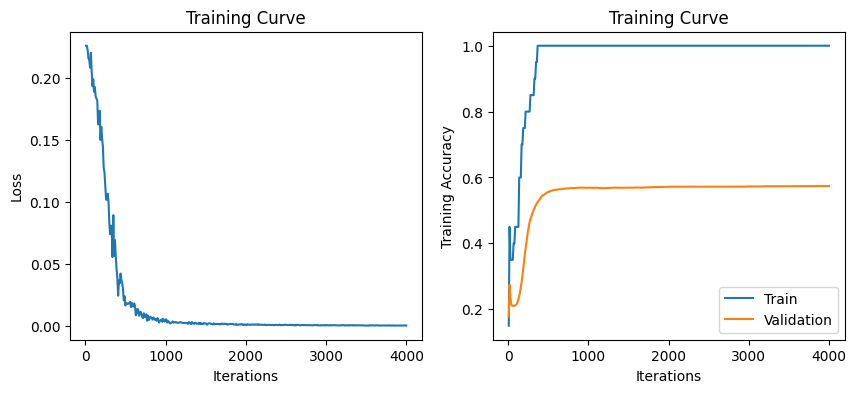

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.5739478957915831


In [42]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000,500,100]).to(device)
train(model, mnist_train, mnist_val, num_epochs=2000, with_plot=True)

Epoch 0, loss: 2.2922756671905518
Epoch 100, loss: 0.9161934852600098
Epoch 200, loss: 0.07864382863044739
Epoch 300, loss: 0.06523130089044571
Epoch 400, loss: 0.032900501042604446
Epoch 500, loss: 0.021633312106132507
Epoch 600, loss: 0.01790933683514595
Epoch 700, loss: 0.012422958388924599
Epoch 800, loss: 0.008892910555005074
Epoch 900, loss: 0.010522579774260521
Epoch 1000, loss: 0.00974235963076353
Epoch 1100, loss: 0.007466394454240799
Epoch 1200, loss: 0.00836273655295372
Epoch 1300, loss: 0.006890288088470697
Epoch 1400, loss: 0.003796849399805069
Epoch 1500, loss: 0.005193973891437054
Epoch 1600, loss: 0.004988332279026508
Epoch 1700, loss: 0.0029186666943132877
Epoch 1800, loss: 0.003945410251617432
Epoch 1900, loss: 0.0035424146335572004


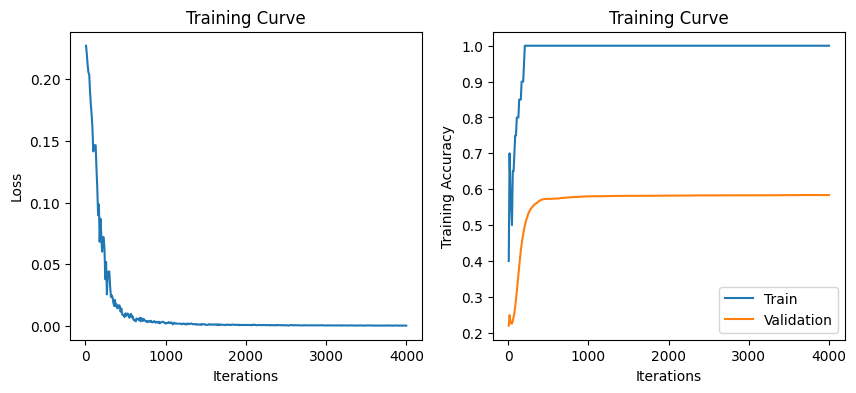

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.5837675350701402


In [43]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000,500]).to(device)
train(model, mnist_train, mnist_val, num_epochs=2000, with_plot=True)

## Reprezentacje danych

In [44]:
adults_data_orig = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",header=None)

In [45]:
adults_data = adults_data_orig.copy()

In [46]:
adults_data.columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "label"]

In [47]:
adults_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [48]:
adults_data['native-country'].value_counts()

native-country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [49]:
adults_data.drop(columns=["native-country","education","workclass","relationship", "marital-status","race"],inplace=True)

In [50]:
adults_data.head()

,age,fnlwgt,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,label
0,39,77516,13,Adm-clerical,Male,2174,0,40,<=50K
1,50,83311,13,Exec-managerial,Male,0,0,13,<=50K
2,38,215646,9,Handlers-cleaners,Male,0,0,40,<=50K
3,53,234721,7,Handlers-cleaners,Male,0,0,40,<=50K
4,28,338409,13,Prof-specialty,Female,0,0,40,<=50K


In [51]:
adults_data.sex = (adults_data.sex==' Male').astype(int)
adults_data.label = (adults_data.label==' >50K').astype(int)

In [52]:
adults_data.head()

,age,fnlwgt,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,label
0,39,77516,13,Adm-clerical,1,2174,0,40,0
1,50,83311,13,Exec-managerial,1,0,0,13,0
2,38,215646,9,Handlers-cleaners,1,0,0,40,0
3,53,234721,7,Handlers-cleaners,1,0,0,40,0
4,28,338409,13,Prof-specialty,0,0,0,40,0


### Get dummies

Dane kategoryczne -> one-hot encoding

In [53]:
adults_data['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [54]:
categorical_columns = ["occupation"]
categorical_values = pd.get_dummies(adults_data[categorical_columns]).astype(int)

categorical_values.head()

,occupation_ ?,occupation_ Adm-clerical,occupation_ Armed-Forces,occupation_ Craft-repair,occupation_ Exec-managerial,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [55]:
adults_data.drop(columns=categorical_columns,inplace=True)

In [56]:
adults_data.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,label
0,39,77516,13,1,2174,0,40,0
1,50,83311,13,1,0,0,13,0
2,38,215646,9,1,0,0,40,0
3,53,234721,7,1,0,0,40,0
4,28,338409,13,0,0,0,40,0


In [57]:
train_indices = np.random.rand(len(adults_data))>0.3

In [58]:
numerical_data = torch.from_numpy(adults_data.values[train_indices,:-1]).float()
categorical_data = torch.from_numpy(categorical_values.values[train_indices]).float()
targets = torch.from_numpy(adults_data.values[train_indices,-1]).float()

test_numerical_data = torch.from_numpy(adults_data.values[~train_indices,:-1]).float()
test_categorical_data = torch.from_numpy(categorical_values.values[~train_indices]).float()
test_targets = torch.from_numpy(adults_data.values[~train_indices,-1]).float()

In [59]:
train_dataset = data.TensorDataset(numerical_data,categorical_data,targets)
test_dataset = data.TensorDataset(test_numerical_data,test_categorical_data,test_targets)

In [60]:
train_dataset[0]

(tensor([3.9000e+01, 7.7516e+04, 1.3000e+01, 1.0000e+00, 2.1740e+03, 0.0000e+00,
         4.0000e+01]),
 tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 tensor(0.))

### Cat numerical and categorical data

In [61]:
class Adults_classifier(nn.Module):
    def __init__(self):
        super(Adults_classifier, self).__init__()
        self.layer1 = nn.Linear(adults_data.shape[1] + categorical_data.shape[1] -1, 40)
        self.act_1 = nn.LeakyReLU()
        self.d1 = nn.Dropout(0.4)
        self.layer2 = nn.Linear(40, 20)
        self.act_2 = nn.LeakyReLU()
        self.d2 = nn.Dropout(0.4)
        self.layer3 = nn.Linear(20, 1)
    def forward(self, x, cat_x):
        x = torch.cat([x,cat_x],dim=1)
        activation1 = self.act_1(self.layer1(x))
        activation1 = self.d1(activation1)
        activation2 = self.act_2(self.layer2(activation1))
        activation2 = self.d1(activation2)
        output = self.layer3(activation2)
        return output

In [62]:
def get_accuracy(model, data_loader):
    correct = 0
    total = 0
    model.eval() #*********#
    for x, cat_x, labels in data_loader:
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        output = model(x, cat_x)
        pred = output>0
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += x.shape[0]
    return correct / total

In [63]:
set_seed(42)
model = Adults_classifier().to(device)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

iters = []
losses = []
train_acc = []
val_acc = []
for n in range(10):
    epoch_losses = []
    model.train()
    for x, cat_x, labels in iter(train_loader):
        optimizer.zero_grad()
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        out = model(x, cat_x).squeeze()
        loss = criterion(out, labels)
        loss.backward()
        epoch_losses.append(loss.item())
        optimizer.step()

    loss_mean = np.array(epoch_losses).mean()
    iters.append(n)
    losses.append(loss_mean)
    test_acc = get_accuracy(model, test_loader)
    print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")
    train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy
    val_acc.append(test_acc)  # compute validation accuracy


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

Epoch 0 loss 3.41e+02 test_acc: 0.762
Epoch 1 loss 26.4 test_acc: 0.765
Epoch 2 loss 17.1 test_acc: 0.766
Epoch 3 loss 11.3 test_acc: 0.766
Epoch 4 loss 7.54 test_acc: 0.766
Epoch 5 loss 4.83 test_acc: 0.768
Epoch 6 loss 3.18 test_acc: 0.765
Epoch 7 loss 1.9 test_acc: 0.769
Epoch 8 loss 1.17 test_acc: 0.767
Epoch 9 loss 0.698 test_acc: 0.765
Final Training Accuracy: 0.7638578502256693
Final Validation Accuracy: 0.7651950718685832


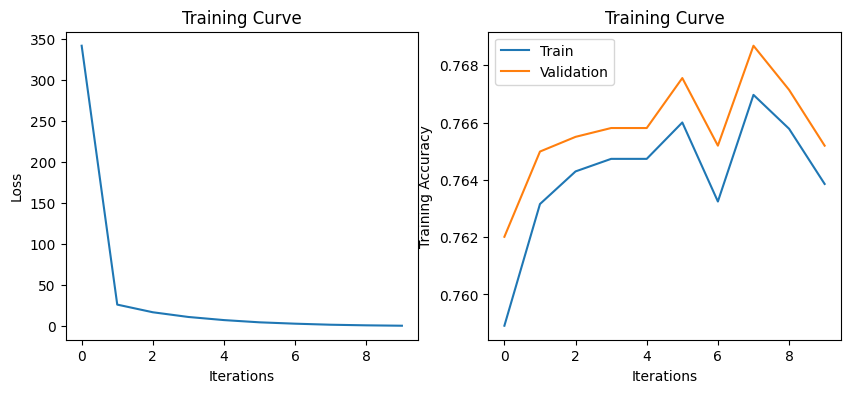

In [64]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Training Curve")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Training Accuracy")
plt.legend(loc='best')
plt.show()

array([[<Axes: title={'center': 'gts'}>]], dtype=object)

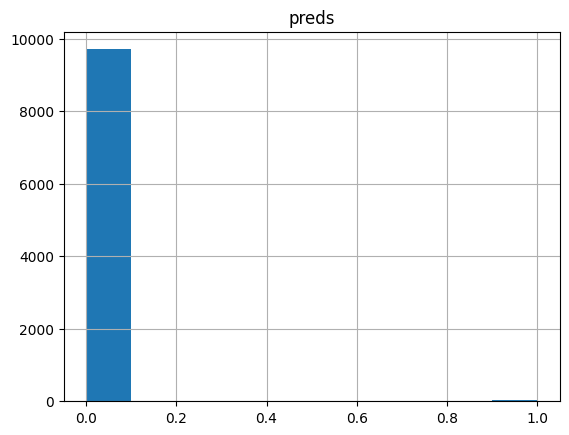

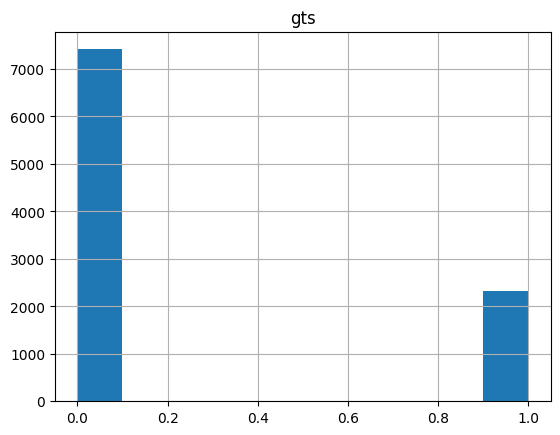

In [65]:
model.eval() #*********#
preds = []
gts = []
for x, cat_x, labels in test_loader:
    x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
    output = model(x, cat_x)
    pred = output>0
    preds.append(pred.cpu().detach().numpy())
    gts.append(labels.cpu().detach().numpy())
preds = np.concatenate(preds)
gts = np.concatenate(gts)

pd.DataFrame(preds.squeeze(), columns=["preds"]).astype(int).hist()
pd.DataFrame(gts.squeeze(), columns=["gts"]).astype(int).hist()

## Embeddings

In [66]:
class Adults_classifier_embeddings(nn.Module):
    def __init__(self):
        super(Adults_classifier_embeddings, self).__init__()
        self.emb_layer = nn.Linear(categorical_data.shape[1], categorical_data.shape[1])
        self.act_emb = nn.Tanh()
        self.layer1 = nn.Linear(adults_data.shape[1] -1 + categorical_data.shape[1], 40)
        self.act_1 =  nn.LeakyReLU()
        self.d1 = nn.Dropout(0.4)
        self.layer2 = nn.Linear(40, 20)
        self.act_2 =  nn.LeakyReLU()
        self.d2 = nn.Dropout(0.4)
        self.layer3 = nn.Linear(20, 1)
    def forward(self, x, cat_x):
        cat_x_embedded = self.emb_layer(cat_x)
        cat_x_embedded = self.act_emb(cat_x_embedded)
        x = torch.cat([x,cat_x_embedded],dim=1)
        activation1 = self.act_1(self.layer1(x))
        activation1 = self.d1(activation1)
        activation2 = self.act_2(self.layer2(activation1))
        activation2 = self.d2(activation2)
        output = self.layer3(activation2)
        return output

In [67]:
set_seed(42)
model = Adults_classifier_embeddings().to(device)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

iters = []
losses = []
train_acc = []
val_acc = []
for n in range(10):
    epoch_losses = []
    for x, cat_x, labels in iter(train_loader):
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        model.train()
        out = model(x, cat_x).squeeze()

        loss = criterion(out, labels)
        loss.backward()
        epoch_losses.append(loss.item())
        optimizer.step()
        optimizer.zero_grad()

    loss_mean = np.array(epoch_losses).mean()
    iters.append(n)
    losses.append(loss_mean)
    test_acc = get_accuracy(model, test_loader)
    print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")
    train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy
    val_acc.append(test_acc)  # compute validation accuracy


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

Epoch 0 loss 1.6e+02 test_acc: 0.767
Epoch 1 loss 8.78 test_acc: 0.767
Epoch 2 loss 5.48 test_acc: 0.765
Epoch 3 loss 3.35 test_acc: 0.766
Epoch 4 loss 1.88 test_acc: 0.767
Epoch 5 loss 1.24 test_acc: 0.767
Epoch 6 loss 0.81 test_acc: 0.768
Epoch 7 loss 0.662 test_acc: 0.768
Epoch 8 loss 0.605 test_acc: 0.768
Epoch 9 loss 0.586 test_acc: 0.768
Final Training Accuracy: 0.7656982603742167
Final Validation Accuracy: 0.7677618069815195


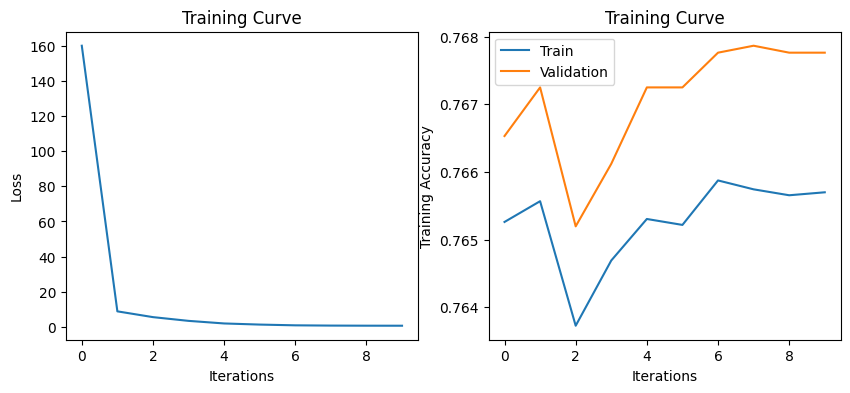

In [68]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Training Curve")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Training Accuracy")
plt.legend(loc='best')
plt.show()

In [69]:
(preds<=0).sum(), (preds>0).sum()

(np.int64(9703), np.int64(37))

## Ważenie przykładów

In [70]:
(len(targets)-sum(targets))/sum(targets)

tensor(3.1365)

In [71]:
model = Adults_classifier_embeddings().to(device)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)
criterion = nn.BCEWithLogitsLoss(pos_weight=(len(targets)-sum(targets))/sum(targets))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

iters = []
losses = []
train_acc = []
val_acc = []
for n in range(30):
    epoch_losses = []
    for x, cat_x, labels in iter(train_loader):
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        model.train()
        out = model(x, cat_x).squeeze()

        loss = criterion(out, labels)
        loss.backward()
        epoch_losses.append(loss.item())
        optimizer.step()
        optimizer.zero_grad()

    loss_mean = np.array(epoch_losses).mean()
    iters.append(n)
    losses.append(loss_mean)
    test_acc = get_accuracy(model, test_loader)
    print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")
    train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy
    val_acc.append(test_acc)  # compute validation accuracy


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

Epoch 0 loss 2.81e+02 test_acc: 0.239
Epoch 1 loss 28.3 test_acc: 0.795
Epoch 2 loss 15.4 test_acc: 0.795
Epoch 3 loss 8.68 test_acc: 0.79
Epoch 4 loss 3.8 test_acc: 0.274
Epoch 5 loss 1.67 test_acc: 0.765
Epoch 6 loss 1.19 test_acc: 0.77
Epoch 7 loss 1.16 test_acc: 0.239
Epoch 8 loss 1.15 test_acc: 0.239
Epoch 9 loss 1.16 test_acc: 0.755
Epoch 10 loss 1.09 test_acc: 0.763
Epoch 11 loss 1.12 test_acc: 0.748
Epoch 12 loss 1.09 test_acc: 0.239
Epoch 13 loss 1.13 test_acc: 0.297
Epoch 14 loss 1.13 test_acc: 0.239
Epoch 15 loss 1.09 test_acc: 0.758
Epoch 16 loss 1.13 test_acc: 0.239
Epoch 17 loss 1.12 test_acc: 0.244
Epoch 18 loss 1.07 test_acc: 0.239
Epoch 19 loss 1.06 test_acc: 0.239
Epoch 20 loss 1.05 test_acc: 0.348
Epoch 21 loss 1.04 test_acc: 0.275
Epoch 22 loss 1.06 test_acc: 0.792
Epoch 23 loss 1.04 test_acc: 0.393
Epoch 24 loss 1.01 test_acc: 0.3
Epoch 25 loss 1.01 test_acc: 0.795
Epoch 26 loss 1.01 test_acc: 0.795
Epoch 27 loss 1.01 test_acc: 0.787
Epoch 28 loss 1.01 test_acc: 0.

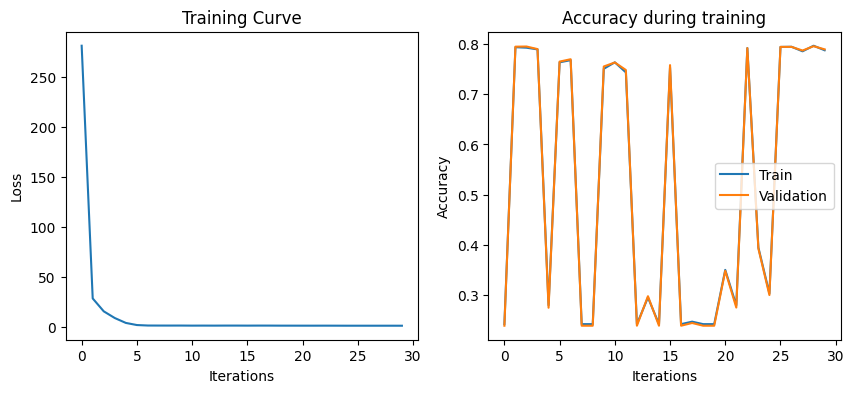

In [72]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Accuracy during training")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()

array([[<Axes: title={'center': 'gts'}>]], dtype=object)

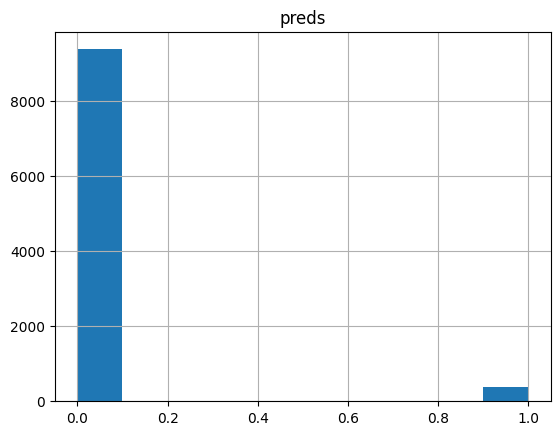

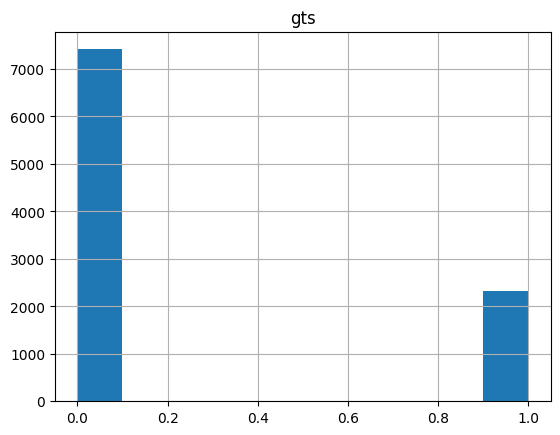

In [73]:
model.eval() #*********#
preds = []
gts = []
for x, cat_x, labels in test_loader:
    x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
    output = model(x, cat_x)
    pred = output>0
    preds.append(pred.cpu().detach().numpy())
    gts.append(labels.cpu().detach().numpy())
preds = np.concatenate(preds)
gts = np.concatenate(gts)

pd.DataFrame(preds.squeeze(), columns=["preds"]).astype(int).hist()
pd.DataFrame(gts.squeeze(), columns=["gts"]).astype(int).hist()

Bonus: https://imbalanced-learn.org/stable/index.html

![](https://www.researchgate.net/profile/Vinod-Kumar-159/publication/361949774/figure/fig2/AS:1177230768119815@1657685095263/Oversampling-and-undersampling-process.png)